In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [7]:
df = pd.read_csv("sp_toxigen_v5.csv")
df = df.drop(columns= "Unnamed: 0")

#remove delimiter rows
df = df[df["Episode"] != "Episode"]

# assign offensiveness class
df["class"] = np.where(df["prob"] > 90, 1, 0) # 0 is not offensive, 1 is offensive
df['Episode'] = df['Episode'].astype(int)
df['Season'] = df['Season'].astype(int)  # Ensure 'Season' is also an integer

In [10]:
offensive_lines = df[df['class'] == 1]
offensive_lines = offensive_lines.sort_values(by = 'prob')
print(len(offensive_lines))
offensive_lines.to_excel("sp_toxigen_offensive_lines.xlsx")

9952


In [29]:
# group by episode, calculate proportion offensive, plot
episode_means = df.groupby(['Season', 'Episode'])['prob'].mean()
episode_props = df.groupby(['Season', 'Episode'])['class'].mean()

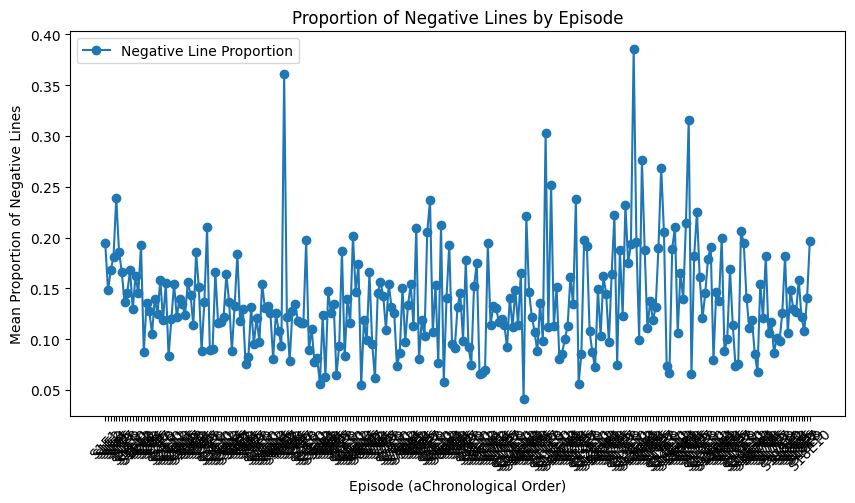

In [42]:
episode_means = df.groupby(['Season', 'Episode'])['class'].mean().reset_index()
episode_means = episode_means.sort_values(by=['Season', 'Episode'])

# Create a continuous x-axis (indexing episodes chronologically)
episode_means['x'] = range(len(episode_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(episode_means['x'], episode_means['class'], marker='o', linestyle='-', label="Negative Line Proportion")

# Customize X-axis labels
plt.xticks(episode_means['x'], labels=[f"S{s}E{e}" for s, e in zip(episode_means['Season'], episode_means['Episode'])], rotation=45)

# Labels and Title
plt.xlabel("Episode (aChronological Order)")
plt.ylabel("Mean Proportion of Negative Lines")
plt.title("Proportion of Negative Lines by Episode")
plt.legend()

plt.show()

In [43]:
# look at high outliers

episode_means = episode_means.sort_values(by = 'class', ascending = False)
episode_means.head()
# may want to remove intentionally inflammatory episodes?
# S13, E12 (gay slur), S5 E1 (shit), S15 E4

,Season,Episode,class,x
192,13,12,0.385714,192
65,5,1,0.361272,65
212,15,4,0.315556,212
160,11,8,0.303279,160
195,14,1,0.276498,195


In [5]:
# group by season, calculate proportion offensive, plot
season_means = df.groupby('Season')['prob'].mean()
season_props = df.groupby('Season')['class'].mean()

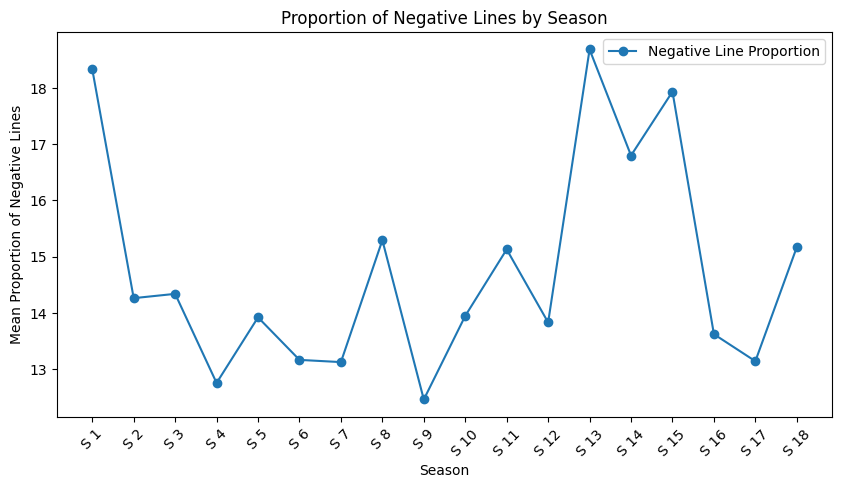

In [44]:
season_means = df.groupby('Season')['prob'].mean().reset_index()
season_means = season_means.sort_values(by=['Season'])

# Create a continuous x-axis (indexing episodes chronologically)
season_means['x'] = range(len(season_means))  # Create a sequential x-axis

# Plot
plt.figure(figsize=(10, 5))
plt.plot(season_means['x'], season_means['prob'], marker='o', linestyle='-', label="Negative Line Proportion")

# Customize X-axis labels
plt.xticks(season_means['x'], labels=[f"S {s}" for s in season_means['Season']], rotation=45)

# Labels and Title
plt.xlabel("Season")
plt.ylabel("Mean Proportion of Negative Lines")
plt.title("Proportion of Negative Lines by Season")
plt.legend()

plt.show()

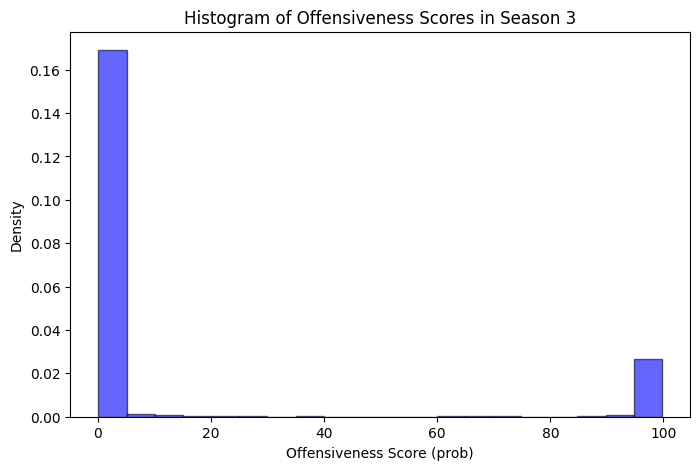

In [54]:
def plot_offensiveness_hist(df, season):
    season_data = df[df['Season'] == season]
    if season_data.empty:
        print(f"No data available for Season {season}.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.hist(season_data['prob'], bins=20, density=True, alpha=0.6, color='blue', edgecolor='black')
    
    plt.xlabel("Offensiveness Score (prob)")
    plt.ylabel("Density")
    plt.title(f"Histogram of Offensiveness Scores in Season {season}")
    
    plt.show()

plot_offensiveness_hist(df, 3)

# none of the distributions are normal
# if restricted to only looking at lines about 80 the distrib is more normal

In [55]:
import scipy.stats as stats

def offensive_proportion_test(df):
    # Categorize lines as offensive (prob 90-100) or non-offensive (prob <90)
    df['class'] = df['class'].astype(int)
    
    # Create a contingency table: rows = seasons, columns = offensive/non-offensive counts
    contingency_table = df.groupby('Season')['class'].value_counts().unstack(fill_value=0)

    # Run Chi-Square test
    chi2, p, _, _ = stats.chi2_contingency(contingency_table)

    return chi2, p, contingency_table

# Example usage:
chi2_stat, p_value, table = offensive_proportion_test(df)
print(f"Chi-Square Statistic: {chi2_stat}, p-value: {p_value}")
print("Contingency Table:\n", table)


Chi-Square Statistic: 178.93847313214138, p-value: 4.698009432125499e-29
Contingency Table:
 class      0    1
Season           
1       3469  701
2       5568  848
3       5031  767
4       5010  670
5       3841  573
6       4504  627
7       3719  517
8       3093  508
9       3121  405
10      3037  434
11      2986  492
12      2890  417
13      2690  567
14      2820  526
15      2585  516
16      2724  396
17      2033  272
18      2166  356


In [77]:
# fisher tests to look at specific seasons
from scipy.stats import fisher_exact

def fisher_test(df, season1, season2):
    df['class'] = df['class'].astype(int)
    
    # Get counts for both seasons
    table = df[df['Season'].isin([season1, season2])].groupby('Season')['class'].value_counts().unstack(fill_value=0)

    # Run Fisher's Exact Test
    oddsratio, p = fisher_exact(table)

    return oddsratio, p, table

# Example usage:
odds_ratio, p_value, table = fisher_test(df, 1, 2)
print(f"Odds Ratio: {odds_ratio}, p-value: {p_value}")
print("Contingency Table:\n", table)

# notably different: 1&2, 7&8, 8&9, 12&13, 15&16

Odds Ratio: 0.7536729138996835, p-value: 3.9766393582279717e-07
Contingency Table:
 class      0    1
Season           
1       3469  701
2       5568  848


In [ ]:
# Q: what happened season 13-15??? A: 2008 economic crisis baby
# run statistical tests to quantify significant difference between seasons
